# Economics Complete Experiment

Compact 20-seed real-data workflow for CMDL, plain LSTM, grouped ARDL, and AC-GATE ablations. The structure matches the other experiment notebooks: configure, optionally run, consolidate, audit, and visualize.

Run switches are off by default because the full 20-seed suite is intentionally expensive. Flip them to regenerate artifacts; otherwise the notebook reads existing outputs from `OUTPUT_ROOT`.


In [1]:
from argparse import Namespace
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next((path for path in [current, *current.parents] if (path / "config").exists() and (path / "data").exists() and (path / "experiments").exists()), None)
if repo_root is None:
    raise RuntimeError(f"Could not find repo root from {current}")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from evaluation import economics_comparison as comparison_module
from experiments import run_economics as cmdl_module
from experiments import run_economics_lstm_baseline as baseline_module
from experiments import run_economics_grouped_ardl as grouped_ardl_module
from experiments import run_economics_ablation as ablation_module

comparison_module = importlib.reload(comparison_module)
cmdl_module = importlib.reload(cmdl_module)
baseline_module = importlib.reload(baseline_module)
grouped_ardl_module = importlib.reload(grouped_ardl_module)
ablation_module = importlib.reload(ablation_module)

build_comparison = comparison_module.build_economics_comparison
build_task_table = comparison_module.build_task_table
build_interpretability_table = comparison_module.build_interpretability_table
build_per_proxy_alignment_table = comparison_module.build_per_proxy_alignment_table
build_per_proxy_audit_summary_table = comparison_module.build_per_proxy_audit_summary_table
build_grouped_ardl_lag_trend_table = comparison_module.build_grouped_ardl_lag_trend_table
build_mechanism_summary_table = comparison_module.build_mechanism_summary_table
build_mechanism_result_log = comparison_module.build_mechanism_result_log
run_cmdl_experiment = cmdl_module.run_experiment
run_baseline_experiment = baseline_module.run_experiment
run_grouped_ardl_experiment = grouped_ardl_module.run_experiment
run_ablation_suite = ablation_module.run_suite

SEEDS = list(range(20))
RUN_CMDL = True
RUN_BASELINE = True
RUN_GROUPED_ARDL = True
RUN_ABLATIONS = True
ACTIVE_PLAN = "complete_20seed_20260426"
FALLBACK_PLAN = "multiseed_audit"

REQUESTED_OUTPUT_ROOT = repo_root / "outputs" / "notebook_economics" / ACTIVE_PLAN
FALLBACK_OUTPUT_ROOT = repo_root / "outputs" / "notebook_economics" / FALLBACK_PLAN
COMPARISON_DIR = REQUESTED_OUTPUT_ROOT / "comparison"
PLOTS_DIR = REQUESTED_OUTPUT_ROOT / "comparison_plots"

PRESET = {"epochs": 120, "patience": 20, "log_every": 10}
COMMON_ARGS = {
    "csv_path": str(repo_root / "data" / "economics" / "processed" / "economics_cleaned_long_v2.csv"),
    "year_start": 1980,
    "year_end": 2023,
    "train_end_year": 2007,
    "val_end_year": 2013,
    "target_column": "ctfp",
    "feature_bundle": "effective_labor_aware",
    "recon_loss_mode": "anchor_weighted",
    "anchor_recon_weight": 2.0,
    "reconstruction_detach": False,
    "grad_clip_mode": "split",
    "max_missing_share": 0.15,
    "lr": 1e-3,
    "lambda_r": 0.1,
    "temperature": 1.0,
    "omega_transform": "softmax",
    "lambda_omega_entropy": 0.0,
    "omega_entropy_min": None,
    "omega_entropy_max": None,
    "lambda_z_anchor": 0.0,
    "z_anchor_target_sign": 1.0,
    "lag_bias_strength": 1.0,
    "grad_clip": 1.0,
    "device": "auto",
    "disable_mlflow": True,
    "smoke": False,
}

def has_summary_artifacts(path: Path) -> bool:
    return path.exists() and any(path.glob("*/summary.json"))

RUN_ANY = RUN_CMDL or RUN_BASELINE or RUN_GROUPED_ARDL or RUN_ABLATIONS
REQUESTED_HAS_RESULTS = any(has_summary_artifacts(REQUESTED_OUTPUT_ROOT / name) for name in ["cmdl", "plain_lstm", "grouped_ardl", "ablation"])
FALLBACK_HAS_RESULTS = any(has_summary_artifacts(FALLBACK_OUTPUT_ROOT / name) for name in ["cmdl", "plain_lstm", "grouped_ardl", "ablation"])
USE_FALLBACK_ARTIFACTS = (not RUN_ANY) and (not REQUESTED_HAS_RESULTS) and FALLBACK_HAS_RESULTS
ARTIFACT_ROOT = FALLBACK_OUTPUT_ROOT if USE_FALLBACK_ARTIFACTS else REQUESTED_OUTPUT_ROOT
ARTIFACT_SOURCE = FALLBACK_PLAN if USE_FALLBACK_ARTIFACTS else ACTIVE_PLAN

OUTPUT_ROOT = REQUESTED_OUTPUT_ROOT
CMDL_DIR = ARTIFACT_ROOT / "cmdl"
BASELINE_DIR = ARTIFACT_ROOT / "plain_lstm"
GROUPED_ARDL_DIR = ARTIFACT_ROOT / "grouped_ardl"
ABLATION_DIR = ARTIFACT_ROOT / "ablation"

for path in [REQUESTED_OUTPUT_ROOT, REQUESTED_OUTPUT_ROOT / "cmdl", REQUESTED_OUTPUT_ROOT / "plain_lstm", REQUESTED_OUTPUT_ROOT / "grouped_ardl", REQUESTED_OUTPUT_ROOT / "ablation", COMPARISON_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

settings = pd.Series(
    {
        "active_plan": ACTIVE_PLAN,
        "artifact_source": ARTIFACT_SOURCE,
        "seed_count_planned": len(SEEDS),
        "seeds_planned": SEEDS,
        "requested_output_root": REQUESTED_OUTPUT_ROOT,
        "artifact_root_resolved": ARTIFACT_ROOT,
        **PRESET,
        **COMMON_ARGS,
    },
    name="value",
).to_frame()
display(settings)

c:\Users\42155\anaconda3\envs\PTenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,value
active_plan,complete_20seed_20260426
artifact_source,complete_20seed_20260426
seed_count_planned,20
seeds_planned,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
requested_output_root,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
artifact_root_resolved,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
epochs,120
patience,20
log_every,10
csv_path,C:\DevSpace\PyDevspace\CMDL\data\economics\pro...


In [2]:
cmdl_summaries = []
baseline_summaries = []
grouped_ardl_summaries = []
ablation_summary_frame = pd.DataFrame()
ablation_aggregated_frame = pd.DataFrame()

for seed in SEEDS:
    shared_args = {**COMMON_ARGS, **PRESET, "seed": seed}
    if RUN_CMDL:
        cmdl_summaries.append(run_cmdl_experiment(Namespace(**shared_args, output_dir=str(CMDL_DIR), experiment_name=f"economics_cmdl_seed{seed}")))
    if RUN_BASELINE:
        baseline_summaries.append(run_baseline_experiment(Namespace(**shared_args, output_dir=str(BASELINE_DIR), experiment_name=f"economics_lstm_seed{seed}")))
    if RUN_GROUPED_ARDL:
        grouped_ardl_summaries.append(run_grouped_ardl_experiment(Namespace(**shared_args, output_dir=str(GROUPED_ARDL_DIR), experiment_name=f"economics_grouped_ardl_seed{seed}")))

if RUN_ABLATIONS:
    ablation_args = Namespace(**COMMON_ARGS, **PRESET, variant="all", seeds=SEEDS, output_dir=str(ABLATION_DIR), experiment_prefix="economics_ablation")
    ablation_summary_frame, ablation_aggregated_frame = run_ablation_suite(ablation_args)
else:
    print("Run switches are off; using existing artifacts if present.")


[economics_cmdl_seed0] epoch=001 train_total=1.9567 val_task=2.9859 val_r2=-0.0789 val_proxy_r2=-0.3824
[economics_cmdl_seed0] epoch=010 train_total=0.6928 val_task=2.4848 val_r2=0.1126 val_proxy_r2=-0.3328
[economics_cmdl_seed0] epoch=020 train_total=0.5186 val_task=2.4850 val_r2=0.0937 val_proxy_r2=-0.2785
[economics_cmdl_seed0] epoch=030 train_total=0.4033 val_task=2.4506 val_r2=0.1068 val_proxy_r2=-0.2212
[economics_cmdl_seed0] early stopping at epoch 37
[economics_lstm_seed0] epoch=001 train_task=1.1782 val_task=2.9468 val_mae=1.3153 val_r2=-0.0617
[economics_lstm_seed0] epoch=010 train_task=0.5742 val_task=2.7411 val_mae=1.2351 val_r2=0.0271
[economics_lstm_seed0] epoch=020 train_task=0.4223 val_task=2.6445 val_mae=1.2789 val_r2=0.0382
[economics_lstm_seed0] epoch=030 train_task=0.2976 val_task=2.7503 val_mae=1.3090 val_r2=-0.0092
[economics_lstm_seed0] early stopping at epoch 38
[economics_cmdl_seed1] epoch=001 train_total=1.0464 val_task=2.9826 val_r2=-0.0697 val_proxy_r2=-0.29

In [3]:
def compact_realdata_summary(frame: pd.DataFrame) -> pd.DataFrame:
    columns = [
        "display_name", "family", "variant", "target_column", "feature_bundle", "n_seeds",
        "test_r2_mean", "test_r2_std", "anchor_adjusted_rho_mean", "anchor_positive_seed_share",
        "mean_proxy_adjusted_rho_mean", "mean_proxy_positive_seed_share", "kstar_std_mean",
        "entropy_mean", "lag_gate_sensitivity_range_mean", "proxy_signal_r2_mean",
    ]
    if frame.empty:
        return pd.DataFrame(columns=columns)
    rows = []
    for keys, group in frame.groupby(["display_name", "family", "variant", "target_column", "feature_bundle"], dropna=False):
        display_name, family, variant, target_column, feature_bundle = keys
        adjusted = pd.to_numeric(group.get("test_effective_kstar_proxy_spearman_adjusted_rho"), errors="coerce")
        mean_adjusted = pd.to_numeric(group.get("test_effective_kstar_proxy_mean_spearman_adjusted_rho"), errors="coerce")
        r2 = pd.to_numeric(group.get("test_r2"), errors="coerce")
        kstd = pd.to_numeric(group.get("test_effective_kstar_std"), errors="coerce")
        proxy_signal = pd.to_numeric(group.get("test_proxy_signal_r2"), errors="coerce")
        entropy = pd.to_numeric(group.get("test_effective_lag_entropy_mean"), errors="coerce")
        lag_range = pd.to_numeric(group.get("test_lag_gate_sensitivity_range"), errors="coerce")
        rows.append({
            "display_name": display_name,
            "family": family,
            "variant": variant,
            "target_column": target_column,
            "feature_bundle": feature_bundle,
            "n_seeds": int(group["seed"].nunique(dropna=True)),
            "test_r2_mean": r2.mean(skipna=True),
            "test_r2_std": r2.std(skipna=True),
            "anchor_adjusted_rho_mean": adjusted.mean(skipna=True),
            "anchor_positive_seed_share": float((adjusted.dropna() > 0).mean()) if not adjusted.dropna().empty else np.nan,
            "mean_proxy_adjusted_rho_mean": mean_adjusted.mean(skipna=True),
            "mean_proxy_positive_seed_share": float((mean_adjusted.dropna() > 0).mean()) if not mean_adjusted.dropna().empty else np.nan,
            "kstar_std_mean": kstd.mean(skipna=True),
            "entropy_mean": entropy.mean(skipna=True),
            "lag_gate_sensitivity_range_mean": lag_range.mean(skipna=True),
            "proxy_signal_r2_mean": proxy_signal.mean(skipna=True),
        })
    return pd.DataFrame(rows, columns=columns).sort_values(["family", "display_name", "variant"], na_position="last").reset_index(drop=True)

comparison = build_comparison(cmdl_root=CMDL_DIR, baseline_root=BASELINE_DIR, ablation_root=ABLATION_DIR, grouped_ardl_root=GROUPED_ARDL_DIR)
task_table = build_task_table(comparison)
interpretability_table = build_interpretability_table(comparison)
per_proxy_table = build_per_proxy_alignment_table(comparison)
per_proxy_audit_summary = build_per_proxy_audit_summary_table(comparison)
grouped_ardl_lag_trend = build_grouped_ardl_lag_trend_table(comparison)
mechanism_summary = build_mechanism_summary_table(comparison)
result_log = build_mechanism_result_log(comparison)
compact_summary = compact_realdata_summary(comparison)
significance_tables = comparison_module.build_significance_tables(comparison)

exports = {
    "economics_comparison.csv": comparison,
    "economics_task_table.csv": task_table,
    "economics_interpretability_table.csv": interpretability_table,
    "economics_per_proxy_adjusted_rho.csv": per_proxy_table,
    "economics_per_proxy_audit_summary.csv": per_proxy_audit_summary,
    "economics_grouped_ardl_lag_trend.csv": grouped_ardl_lag_trend,
    "economics_mechanism_summary.csv": mechanism_summary,
    "economics_result_log.csv": result_log,
    "economics_compact_summary.csv": compact_summary,
    **significance_tables,
}
for name, frame in exports.items():
    frame.to_csv(COMPARISON_DIR / name, index=False)

print(f"comparison rows = {len(comparison)}")
display(compact_summary)
display(result_log)


comparison rows = 120


,display_name,family,variant,target_column,feature_bundle,n_seeds,test_r2_mean,test_r2_std,anchor_adjusted_rho_mean,anchor_positive_seed_share,mean_proxy_adjusted_rho_mean,mean_proxy_positive_seed_share,kstar_std_mean,entropy_mean,lag_gate_sensitivity_range_mean,proxy_signal_r2_mean
0,No AC Encoder,ablation,no_ac_encoder,ctfp,effective_labor_aware,20,0.051821,0.035362,NaN,NaN,NaN,NaN,0.000000,1.839098,0.000000,NaN
1,No Recon Regularization,ablation,no_recon_regularization,ctfp,effective_labor_aware,20,0.055259,0.032937,0.163773,0.60,0.311643,0.70,0.109203,1.844385,0.338775,0.220789
2,Uniform Lag,ablation,uniform_lag,ctfp,effective_labor_aware,20,0.103965,0.028008,NaN,NaN,NaN,NaN,0.000000,2.302585,0.734900,0.334655
3,CMDL,cmdl,NaN,ctfp,effective_labor_aware,20,0.054146,0.037323,-0.108693,0.35,-0.038753,0.45,0.167289,1.852977,0.499122,0.305193
4,Grouped ARDL,grouped_ardl,NaN,ctfp,effective_labor_aware,20,-0.089107,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Plain LSTM,plain_lstm,NaN,ctfp,effective_labor_aware,20,0.102420,0.021353,-0.017295,0.25,-0.117040,0.05,1.894237,1.872628,NaN,NaN


,layer,question,answer,evidence
0,forecast_calibration,Does CMDL beat the matched LSTM?,no,"mean CMDL test_r2=0.05414579722609828, mean Pl..."
1,simple_baseline_calibration,Is CMDL above the simple calibrated baselines?,partial,"delta_vs_persistence=-0.8826874050038962, delt..."
2,ac_gate_mechanism,Does the anchor-adjusted lag-proxy direction s...,partial,"CMDL mean adjusted rho=-0.10869306317884078, p..."
3,ac_gate_per_proxy,Are all named proxy adjusted correlations alig...,partial,"candidate_positive_proxies=1/4, min_adjusted_r..."
4,ac_gate_heterogeneity,Is the learned lag gate non-degenerate?,yes,lag_gate_sensitivity_range=0.49912182092666624...
5,ablation_guard,Do degenerate controls expose the heterogeneit...,yes,"No AC kstar_std=0.0, Uniform Lag top1_share=1.0."


,display_name,family,variant,seed,experiment,target_column,feature_bundle,best_epoch,best_val_task_loss,test_r2,test_baseline_persistence_r2,test_baseline_panel_ols_r2,test_baseline_grouped_ardl_r2,test_baseline_best_simple_r2,test_r2_delta_vs_persistence,test_r2_delta_vs_panel_ols,test_r2_delta_vs_grouped_ardl,test_mae,test_mse
0,Uniform Lag,ablation,uniform_lag,5,economics_ablation_uniform_lag_seed5,ctfp,effective_labor_aware,60,2.223125,0.160385,0.936833,0.021006,-0.089107,0.936833,-0.776449,0.139379,0.249492,1.441702,3.367517
1,Uniform Lag,ablation,uniform_lag,2,economics_ablation_uniform_lag_seed2,ctfp,effective_labor_aware,76,2.372164,0.147609,0.936833,0.021006,-0.089107,0.936833,-0.789224,0.126603,0.236716,1.414471,3.424064
2,Uniform Lag,ablation,uniform_lag,8,economics_ablation_uniform_lag_seed8,ctfp,effective_labor_aware,78,2.120614,0.146409,0.936833,0.021006,-0.089107,0.936833,-0.790424,0.125403,0.235516,1.413048,3.430443
3,Plain LSTM,plain_lstm,None,7,economics_lstm_seed7,ctfp,effective_labor_aware,21,2.416419,0.142644,0.936833,0.021006,-0.089107,0.936833,-0.794190,0.121638,0.231751,1.415268,3.444896
4,Plain LSTM,plain_lstm,None,19,economics_lstm_seed19,ctfp,effective_labor_aware,77,2.387555,0.137510,0.936833,0.021006,-0.089107,0.936833,-0.799323,0.116505,0.226617,1.405881,3.460453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Grouped ARDL,grouped_ardl,None,15,economics_grouped_ardl_seed15,ctfp,effective_labor_aware,0,2.340800,-0.089107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.567527,4.401832
116,Grouped ARDL,grouped_ardl,None,16,economics_grouped_ardl_seed16,ctfp,effective_labor_aware,0,2.340800,-0.089107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.567527,4.401832
117,Grouped ARDL,grouped_ardl,None,17,economics_grouped_ardl_seed17,ctfp,effective_labor_aware,0,2.340800,-0.089107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.567527,4.401832
118,Grouped ARDL,grouped_ardl,None,18,economics_grouped_ardl_seed18,ctfp,effective_labor_aware,0,2.340800,-0.089107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.567527,4.401832


,display_name,family,variant,seed,experiment,target_column,feature_bundle,lag_method,anchor_proxy_name,anchor_expected_sign,...,test_lag_gate_sensitivity_slope,test_lag_gate_sensitivity_range,test_proxy_signal_r2,test_proxy_signal_metric_valid,omega_transform,lambda_omega_entropy,omega_entropy_min,omega_entropy_max,lambda_z_anchor,z_anchor_target_sign
0,CMDL,cmdl,None,4,economics_cmdl_seed4,ctfp,effective_labor_aware,learned_omega,proxy_effective_labor_anchor,-1.0,...,1.247928,1.487225,0.406467,True,softmax,0.0,None,None,0.0,1.0
1,CMDL,cmdl,None,13,economics_cmdl_seed13,ctfp,effective_labor_aware,learned_omega,proxy_effective_labor_anchor,-1.0,...,-0.475421,0.106335,0.291291,True,softmax,0.0,None,None,0.0,1.0
2,CMDL,cmdl,None,16,economics_cmdl_seed16,ctfp,effective_labor_aware,learned_omega,proxy_effective_labor_anchor,-1.0,...,0.430860,0.178395,0.337207,True,softmax,0.0,None,None,0.0,1.0
3,CMDL,cmdl,None,7,economics_cmdl_seed7,ctfp,effective_labor_aware,learned_omega,proxy_effective_labor_anchor,-1.0,...,0.109289,0.087214,0.369076,True,softmax,0.0,None,None,0.0,1.0
4,CMDL,cmdl,None,9,economics_cmdl_seed9,ctfp,effective_labor_aware,learned_omega,proxy_effective_labor_anchor,-1.0,...,-1.161486,0.411185,0.275369,True,softmax,0.0,None,None,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,No AC Encoder,ablation,no_ac_encoder,15,economics_ablation_no_ac_encoder_seed15,ctfp,effective_labor_aware,learned_omega,proxy_effective_labor_anchor,-1.0,...,NaN,0.000000,NaN,False,softmax,0.0,None,None,0.0,1.0
116,No AC Encoder,ablation,no_ac_encoder,16,economics_ablation_no_ac_encoder_seed16,ctfp,effective_labor_aware,learned_omega,proxy_effective_labor_anchor,-1.0,...,NaN,0.000000,NaN,False,softmax,0.0,None,None,0.0,1.0
117,No AC Encoder,ablation,no_ac_encoder,17,economics_ablation_no_ac_encoder_seed17,ctfp,effective_labor_aware,learned_omega,proxy_effective_labor_anchor,-1.0,...,NaN,0.000000,NaN,False,softmax,0.0,None,None,0.0,1.0
118,No AC Encoder,ablation,no_ac_encoder,18,economics_ablation_no_ac_encoder_seed18,ctfp,effective_labor_aware,learned_omega,proxy_effective_labor_anchor,-1.0,...,NaN,0.000000,NaN,False,softmax,0.0,None,None,0.0,1.0


,display_name,family,variant,target_column,feature_bundle,anchor_proxy_name,proxy_index,proxy_name,expected_sign,n_seeds,n_valid,rho_mean,rho_std,adjusted_rho_mean,adjusted_rho_std,adjusted_rho_min,adjusted_rho_max,positive_seed_share,p_value_median,mechanism_status
0,CMDL,cmdl,NaN,ctfp,effective_labor_aware,proxy_effective_labor_anchor,1,effective_labor_anchor,-1.0,20,20,0.108693,0.637576,-0.108693,0.637576,-0.915801,0.948100,0.35,1.559837e-07,mixed_or_negative
1,CMDL,cmdl,NaN,ctfp,effective_labor_aware,proxy_effective_labor_anchor,2,employment_level,-1.0,20,20,0.100981,0.641363,-0.100981,0.641363,-0.904054,0.958596,0.35,7.098926e-09,mixed_or_negative
2,CMDL,cmdl,NaN,ctfp,effective_labor_aware,proxy_effective_labor_anchor,3,hc_level,-1.0,20,20,-0.142912,0.402474,0.142912,0.402474,-0.587563,0.806418,0.70,5.812737e-04,candidate_positive
3,CMDL,cmdl,NaN,ctfp,effective_labor_aware,proxy_effective_labor_anchor,4,hc_trend,-1.0,20,20,0.046010,0.423259,-0.046010,0.423259,-0.798792,0.786499,0.50,2.831507e-03,mixed_or_negative


,display_name,family,seed,experiment,target_column,feature_bundle,anchor_proxy_name,anchor_expected_sign,group,group_order,best_lag,effective_lag,deterministic_baseline
0,Grouped ARDL,grouped_ardl,0,economics_grouped_ardl_seed0,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,low,1,10.0,6.070965,True
1,Grouped ARDL,grouped_ardl,0,economics_grouped_ardl_seed0,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,mid,2,1.0,4.823772,True
2,Grouped ARDL,grouped_ardl,0,economics_grouped_ardl_seed0,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,high,3,2.0,5.636658,True
3,Grouped ARDL,grouped_ardl,1,economics_grouped_ardl_seed1,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,low,1,10.0,6.070965,True
4,Grouped ARDL,grouped_ardl,1,economics_grouped_ardl_seed1,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,mid,2,1.0,4.823772,True
5,Grouped ARDL,grouped_ardl,1,economics_grouped_ardl_seed1,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,high,3,2.0,5.636658,True
6,Grouped ARDL,grouped_ardl,2,economics_grouped_ardl_seed2,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,low,1,10.0,6.070965,True
7,Grouped ARDL,grouped_ardl,2,economics_grouped_ardl_seed2,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,mid,2,1.0,4.823772,True
8,Grouped ARDL,grouped_ardl,2,economics_grouped_ardl_seed2,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,high,3,2.0,5.636658,True
9,Grouped ARDL,grouped_ardl,3,economics_grouped_ardl_seed3,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,low,1,10.0,6.070965,True


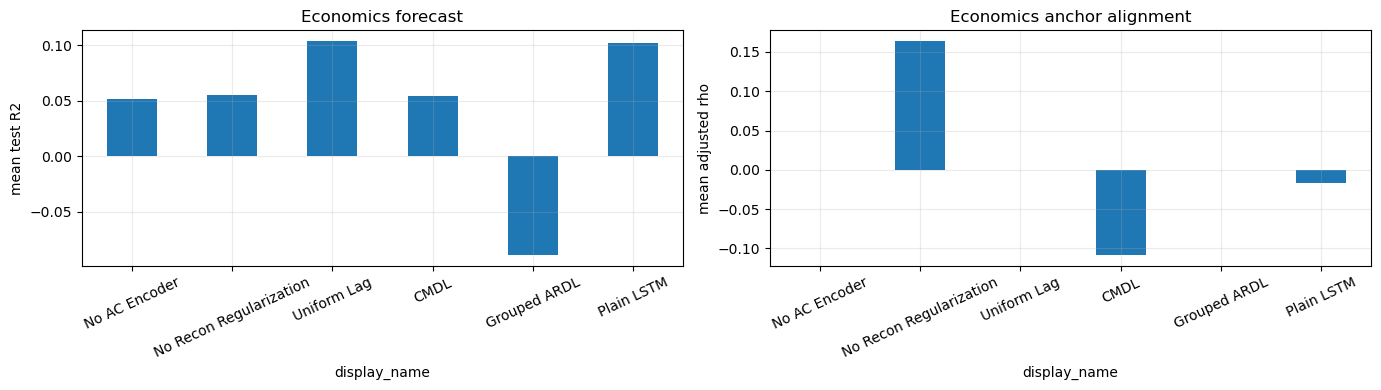

Saved plot to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\complete_20seed_20260426\comparison_plots\economics_multiseed_summary.png


In [4]:
if comparison.empty:
    print("No economics artifacts found yet. Enable run switches or point OUTPUT_ROOT to an existing run directory.")
else:
    display(task_table)
    display(interpretability_table)
    display(per_proxy_audit_summary)
    display(grouped_ardl_lag_trend)
    plot_frame = compact_summary.copy()
    if not plot_frame.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        plot_frame.plot(x="display_name", y="test_r2_mean", kind="bar", ax=axes[0], legend=False)
        axes[0].set_title("Economics forecast")
        axes[0].set_ylabel("mean test R2")
        axes[0].tick_params(axis="x", rotation=25)
        axes[0].grid(alpha=0.25)
        plot_frame.plot(x="display_name", y="anchor_adjusted_rho_mean", kind="bar", ax=axes[1], legend=False)
        axes[1].set_title("Economics anchor alignment")
        axes[1].set_ylabel("mean adjusted rho")
        axes[1].tick_params(axis="x", rotation=25)
        axes[1].grid(alpha=0.25)
        fig.tight_layout()
        plot_path = PLOTS_DIR / "economics_multiseed_summary.png"
        fig.savefig(plot_path, dpi=160, bbox_inches="tight")
        display(fig)
        plt.close(fig)
        print(f"Saved plot to {plot_path}")


## Stratified k* analysis (L2 mechanism evidence)

Per-entity effective lag k* learned by each method is correlated against entity-level static development indicators measured on the train window only (no leakage). Significance comes from a 2000-permutation entity-shuffle null per seed, then aggregated across 20 seeds via Fisher's combined p. We report `abs_rho_mean` and the share of seeds rejecting the null at p<0.05 because un-supervised structure discovery has label-permutation symmetry that flips the sign of rho across seeds.

Degenerate ablations (No AC Encoder, Uniform Lag) collapse k* to a constant, so the stratification test is structurally inapplicable for them — that itself is the strongest L2 ablation control.

In [5]:
from evaluation.stratified_kstar import (
    aggregate_per_method,
    build_economics_stratifiers,
    collect_seed_dirs,
    evaluate_method,
)

ECON_RAW = repo_root / "data" / "economics" / "processed" / "economics_cleaned_long_v2.csv"
strats = build_economics_stratifiers(ECON_RAW)

methods = {
    "CMDL": collect_seed_dirs(CMDL_DIR, "economics_cmdl_"),
    "Plain LSTM": collect_seed_dirs(BASELINE_DIR, "economics_lstm_"),
    "No AC Encoder": collect_seed_dirs(ABLATION_DIR, "economics_ablation_no_ac_encoder_"),
    "Uniform Lag": collect_seed_dirs(ABLATION_DIR, "economics_ablation_uniform_lag_"),
    "No Recon Reg": collect_seed_dirs(ABLATION_DIR, "economics_ablation_no_recon_regularization_"),
}

per_seed_frames = []
for name, dirs in methods.items():
    if not dirs:
        print(f"skip {name} (no seed dirs)")
        continue
    per_seed_frames.append(evaluate_method(name, dirs, strats, n_perm=2000))

stratified_per_seed = pd.concat(per_seed_frames, ignore_index=True)
stratified_aggregated = aggregate_per_method(stratified_per_seed)

stratified_per_seed.to_csv(COMPARISON_DIR / "economics_stratified_kstar_per_seed.csv", index=False)
stratified_aggregated.to_csv(COMPARISON_DIR / "economics_stratified_kstar_aggregated.csv", index=False)

print(f"valid (seed x stratifier) rows = {stratified_per_seed['spearman_rho'].notna().sum()}")
display(stratified_aggregated)

valid (seed x stratifier) rows = 120


,method,stratifier,n_seeds_total,n_seeds_valid,rho_mean,rho_median,abs_rho_mean,share_seeds_p_lt_05,share_seeds_p_lt_01,fisher_combined_p
0,CMDL,hc_mean_train,20,20,-0.141652,-0.295865,0.370599,0.80,0.75,1.009779e-46
1,CMDL,log_capital_per_worker_train,20,20,-0.099347,-0.135210,0.256791,0.65,0.50,1.382788e-24
2,CMDL,log_gdp_per_worker_train,20,20,-0.109463,-0.146094,0.278268,0.70,0.55,3.494823e-37
3,No AC Encoder,hc_mean_train,20,0,NaN,NaN,NaN,NaN,NaN,NaN
4,No AC Encoder,log_capital_per_worker_train,20,0,NaN,NaN,NaN,NaN,NaN,NaN
5,No AC Encoder,log_gdp_per_worker_train,20,0,NaN,NaN,NaN,NaN,NaN,NaN
6,No Recon Reg,hc_mean_train,20,20,-0.218442,-0.298308,0.418462,0.80,0.65,1.533543e-50
7,No Recon Reg,log_capital_per_worker_train,20,20,-0.112154,-0.123816,0.271589,0.60,0.45,6.137482e-30
8,No Recon Reg,log_gdp_per_worker_train,20,20,-0.111099,-0.126035,0.286881,0.65,0.45,2.481622e-31
9,Plain LSTM,hc_mean_train,20,0,NaN,NaN,NaN,NaN,NaN,NaN


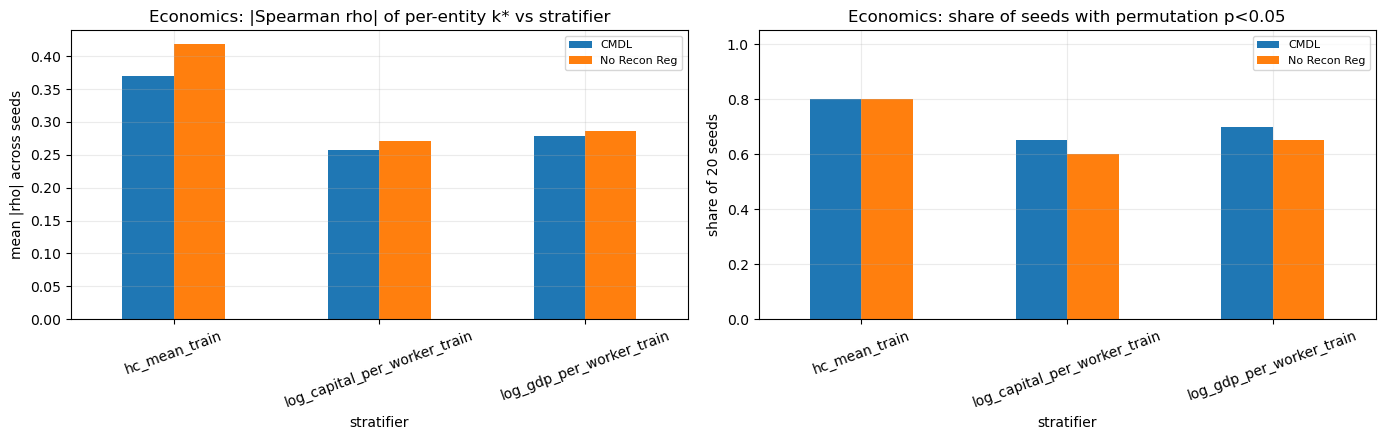

saved C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\complete_20seed_20260426\comparison_plots\economics_stratified_kstar.png


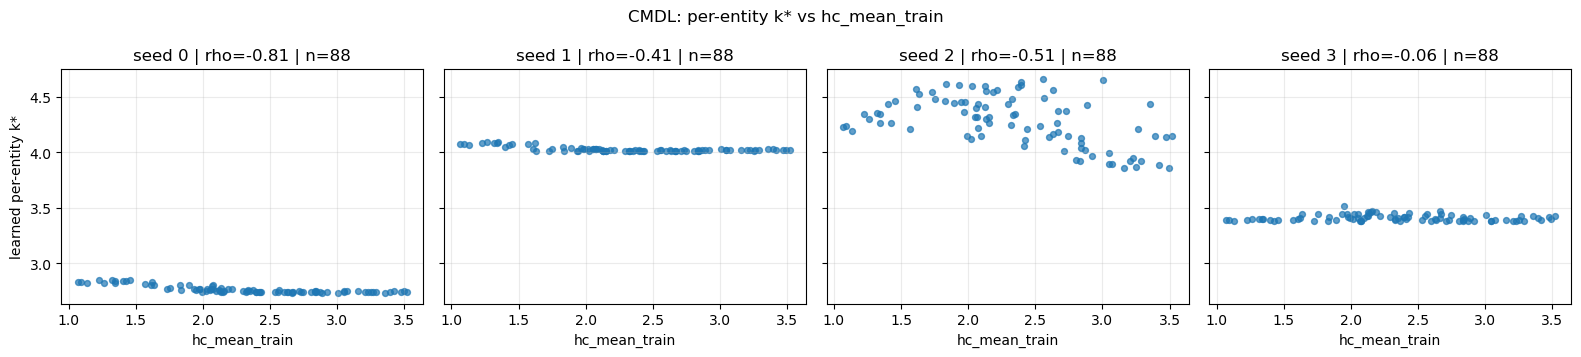

saved C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\complete_20seed_20260426\comparison_plots\economics_kstar_scatter_cmdl_hc_mean_train.png


In [6]:
def plot_stratified_summary(agg: pd.DataFrame, save_to: Path, title: str) -> None:
    if agg.empty:
        print("no stratified results to plot")
        return
    valid = agg[agg["n_seeds_valid"] > 0].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    pivot_abs = valid.pivot(index="stratifier", columns="method", values="abs_rho_mean")
    pivot_share = valid.pivot(index="stratifier", columns="method", values="share_seeds_p_lt_05")
    pivot_abs.plot(kind="bar", ax=axes[0])
    axes[0].set_title(f"{title}: |Spearman rho| of per-entity k* vs stratifier")
    axes[0].set_ylabel("mean |rho| across seeds")
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)
    pivot_share.plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"{title}: share of seeds with permutation p<0.05")
    axes[1].set_ylabel("share of 20 seeds")
    axes[1].set_ylim(0, 1.05)
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(save_to, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"saved {save_to}")

plot_stratified_summary(
    stratified_aggregated,
    PLOTS_DIR / "economics_stratified_kstar.png",
    title="Economics",
)


def plot_kstar_vs_stratifier(method_name: str, dirs: dict[int, Path], spec, n_seeds: int = 4):
    seeds = sorted(dirs.keys())[:n_seeds]
    if not seeds:
        return
    fig, axes = plt.subplots(1, len(seeds), figsize=(4 * len(seeds), 3.6), sharey=True)
    if len(seeds) == 1:
        axes = [axes]
    for ax, seed in zip(axes, seeds):
        df = pd.read_csv(dirs[seed] / "predictions.csv")
        ks = df.groupby("entity_code")["k_star"].first()
        joined = pd.concat([ks.rename("kstar"), spec.series.rename("strat")], axis=1, join="inner").dropna()
        ax.scatter(joined["strat"], joined["kstar"], s=18, alpha=0.7)
        rho = joined.corr(method="spearman").iloc[0, 1]
        ax.set_title(f"seed {seed} | rho={rho:.2f} | n={len(joined)}")
        ax.set_xlabel(spec.name)
        ax.grid(alpha=0.25)
    axes[0].set_ylabel("learned per-entity k*")
    fig.suptitle(f"{method_name}: per-entity k* vs {spec.name}")
    fig.tight_layout()
    out_path = PLOTS_DIR / f"economics_kstar_scatter_{method_name.replace(' ', '_').lower()}_{spec.name}.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"saved {out_path}")

# Strongest stratifier in economics: hc_mean_train (Fisher p ~ 1e-46)
hc_spec = next(s for s in strats if s.name == "hc_mean_train")
plot_kstar_vs_stratifier("CMDL", methods["CMDL"], hc_spec, n_seeds=4)